# 8 Deep Learning

## 8.1
Use a pre-trained ResNet50 and VGG16 on **Keras** to run inference on the test image `car.jpg` in this directory.
* Reference: <https://keras.io/applications/>
* See `08.1_deeplearning_keras.ipynb` for starter code.

## 8.2
Use a pre-trained ResNet50 and VGG16 on **PyTorch** to run inference on the same test image.
* Reference: https://pytorch.org/vision/stable/models.html
* See `08.2_deeplearning_pytorch.ipynb` for starter code.

## 8.3
Compare the inference times of both networks (ResNet50, VGG16) and both frameworks (Keras, PyTorch).

## 8.4
Find two images that are correctly classified and two that are incorrectly classified.

## 8.5
Compare the inference time for TensorFlow/Keras on GPUs vs. CPUs.

TensorFlow: 2.19.0
PyTorch: 2.10.0+cu128


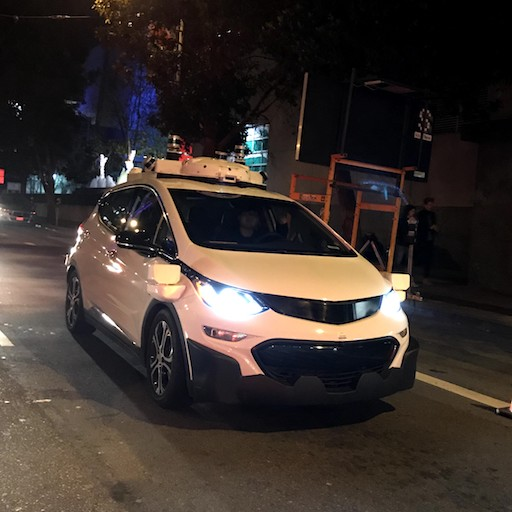

In [22]:
import os
import time
import urllib.request
import numpy as np
import pandas as pd
import torch
from torchvision import models
from PIL import Image, ImageFilter, ImageOps
from IPython.display import display, Image as IPyImage


os.environ["KERAS_BACKEND"] = "tensorflow"

import tensorflow as tf
import keras
from keras.preprocessing import image
from keras.applications.resnet50 import (
    ResNet50,
    preprocess_input as resnet_preprocess_input,
    decode_predictions as resnet_decode_predictions,
)
from keras.applications.vgg16 import (
    VGG16,
    preprocess_input as vgg_preprocess_input,
    decode_predictions as vgg_decode_predictions,
)


CAR_URL = "https://raw.githubusercontent.com/scalable-infrastructure/exercise-2026/main/07_DeepLearning/car.jpg"
IMG_PATH = "car.jpg"

if not os.path.exists(IMG_PATH):
    urllib.request.urlretrieve(CAR_URL, IMG_PATH)

print("TensorFlow:", tf.__version__)
print("PyTorch:", torch.__version__)
display(IPyImage(filename=IMG_PATH, width=500))

def load_keras_input(img_path, preprocess_fn):
    img = image.load_img(img_path, target_size=(224, 224))
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_fn(x.copy())
    return x

def benchmark_keras_model(model_fn, x, runs=20, warmup=3, device_name="/CPU:0"):
    x_tensor = tf.convert_to_tensor(x)

    with tf.device(device_name):
        model = model_fn(weights="imagenet")

        for _ in range(warmup):
            _ = model(x_tensor, training=False).numpy()

        times = []
        for _ in range(runs):
            t0 = time.perf_counter()
            _ = model(x_tensor, training=False).numpy()
            times.append(time.perf_counter() - t0)

    return float(np.mean(times)), float(np.std(times))

def benchmark_torch_model(model, input_batch, runs=20, warmup=3, device="cpu"):
    model = model.to(device)
    input_batch = input_batch.to(device)
    model.eval()

    with torch.no_grad():
        for _ in range(warmup):
            _ = model(input_batch)

        times = []
        for _ in range(runs):
            if device == "cuda":
                torch.cuda.synchronize()

            t0 = time.perf_counter()
            _ = model(input_batch)

            if device == "cuda":
                torch.cuda.synchronize()

            times.append(time.perf_counter() - t0)

    return float(np.mean(times)), float(np.std(times))

def predict_keras_top1(img_path, model, preprocess_fn, decode_fn):
    x = load_keras_input(img_path, preprocess_fn)
    preds = model.predict(x, verbose=0)
    top = decode_fn(preds, top=5)[0]
    return top[0][1], float(top[0][2]), top

def is_car_like_prediction(label):
    label_norm = label.lower().replace("_", " ")
    keywords = [
        "sports car",
        "convertible",
        "racer",
        "car",
    ]
    return any(k in label_norm for k in keywords)

In [23]:
# ---------- global switches ----------
TF_DEVICE = "/GPU:0"   # "/CPU:0" oder "/GPU:0"
TORCH_DEVICE = "cuda"  # "cpu" oder "cuda"

print("TensorFlow GPUs:", tf.config.list_physical_devices("GPU"))
print("PyTorch CUDA available:", torch.cuda.is_available())

# Fallbacks, falls GPU nicht sichtbar ist
if TF_DEVICE == "/GPU:0" and not tf.config.list_physical_devices("GPU"):
    print("TensorFlow GPU nicht verfügbar, fallback auf CPU.")
    TF_DEVICE = "/CPU:0"

if TORCH_DEVICE == "cuda" and not torch.cuda.is_available():
    print("PyTorch CUDA nicht verfügbar, fallback auf CPU.")
    TORCH_DEVICE = "cpu"

print("Using TF device:", TF_DEVICE)
print("Using Torch device:", TORCH_DEVICE)

TensorFlow GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
PyTorch CUDA available: True
Using TF device: /GPU:0
Using Torch device: cuda


In [24]:
#8.3

x_resnet_keras = load_keras_input(IMG_PATH, resnet_preprocess_input)
x_vgg_keras = load_keras_input(IMG_PATH, vgg_preprocess_input)


pil_img = Image.open(IMG_PATH).convert("RGB")

torch_resnet_weights = models.ResNet50_Weights.DEFAULT
torch_vgg_weights = models.VGG16_Weights.DEFAULT

torch_resnet50 = models.resnet50(weights=torch_resnet_weights)
torch_vgg16 = models.vgg16(weights=torch_vgg_weights)

x_resnet_torch = torch_resnet_weights.transforms()(pil_img).unsqueeze(0)
x_vgg_torch = torch_vgg_weights.transforms()(pil_img).unsqueeze(0)

results_83 = []

mean_s, std_s = benchmark_keras_model(ResNet50, x_resnet_keras, device_name=TF_DEVICE)
results_83.append({
    "framework": "Keras",
    "model": "ResNet50",
    "device": TF_DEVICE,
    "mean_ms": mean_s * 1000,
    "std_ms": std_s * 1000,
})

mean_s, std_s = benchmark_keras_model(VGG16, x_vgg_keras, device_name=TF_DEVICE)
results_83.append({
    "framework": "Keras",
    "model": "VGG16",
    "device": TF_DEVICE,
    "mean_ms": mean_s * 1000,
    "std_ms": std_s * 1000,
})

mean_s, std_s = benchmark_torch_model(torch_resnet50, x_resnet_torch, device=TORCH_DEVICE)
results_83.append({
    "framework": "PyTorch",
    "model": "ResNet50",
    "device": TORCH_DEVICE,
    "mean_ms": mean_s * 1000,
    "std_ms": std_s * 1000,
})

mean_s, std_s = benchmark_torch_model(torch_vgg16, x_vgg_torch, device=TORCH_DEVICE)
results_83.append({
    "framework": "PyTorch",
    "model": "VGG16",
    "device": TORCH_DEVICE,
    "mean_ms": mean_s * 1000,
    "std_ms": std_s * 1000,
})

df_83 = pd.DataFrame(results_83)
display(df_83)

,framework,model,device,mean_ms,std_ms
0,Keras,ResNet50,/GPU:0,215.284471,5.666302
1,Keras,VGG16,/GPU:0,34.403392,1.509247
2,PyTorch,ResNet50,cuda,8.096204,0.241656
3,PyTorch,VGG16,cuda,9.295756,0.555927


,image,variant,model,prediction,confidence,correct
0,generated_images/tiny_upscaled.jpg,tiny_upscaled,ResNet50,convertible,16.953258,True
1,generated_images/center_crop_large.jpg,center_crop_large,VGG16,minivan,90.764672,False
2,generated_images/mirror.jpg,mirror,VGG16,minivan,86.106533,False
3,generated_images/original.jpg,original,VGG16,minivan,74.129945,False
4,generated_images/grayscale.jpg,grayscale,ResNet50,minivan,72.750926,False
5,generated_images/posterized.jpg,posterized,ResNet50,minivan,71.209490,False
6,generated_images/grayscale.jpg,grayscale,VGG16,minivan,66.624182,False
7,generated_images/mirror.jpg,mirror,ResNet50,minivan,65.112919,False
8,generated_images/center_crop_small.jpg,center_crop_small,ResNet50,minivan,64.775336,False
9,generated_images/posterized.jpg,posterized,VGG16,minivan,52.328873,False


Two correctly classified examples:


,image,variant,model,prediction,confidence
0,generated_images/tiny_upscaled.jpg,tiny_upscaled,ResNet50,convertible,16.953258


Two incorrectly classified examples:


,image,variant,model,prediction,confidence
1,generated_images/center_crop_large.jpg,center_crop_large,VGG16,minivan,90.764672
2,generated_images/mirror.jpg,mirror,VGG16,minivan,86.106533


=== Correctly classified examples ===


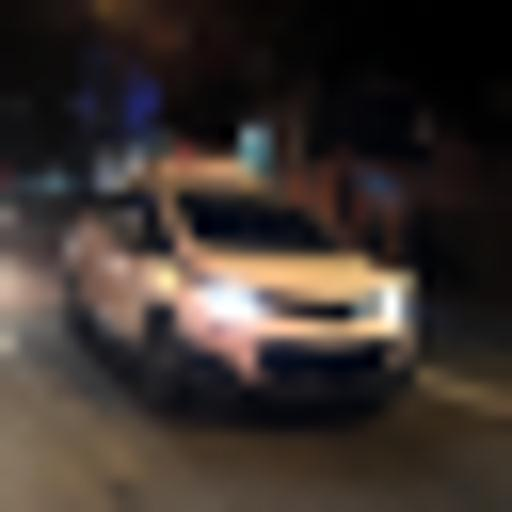

Variant: tiny_upscaled
Model: ResNet50
Prediction: convertible (16.95%)

=== Incorrectly classified examples ===


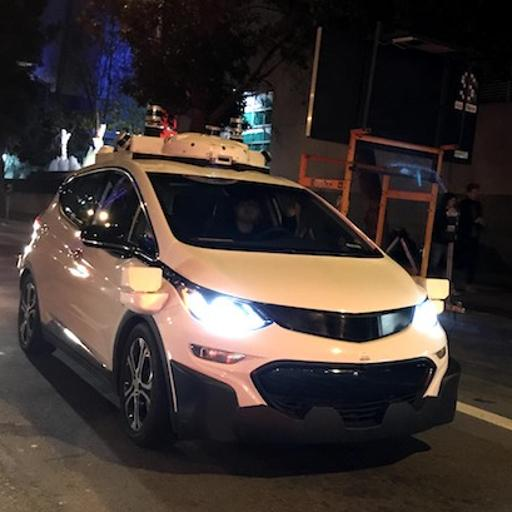

Variant: center_crop_large
Model: VGG16
Prediction: minivan (90.76%)



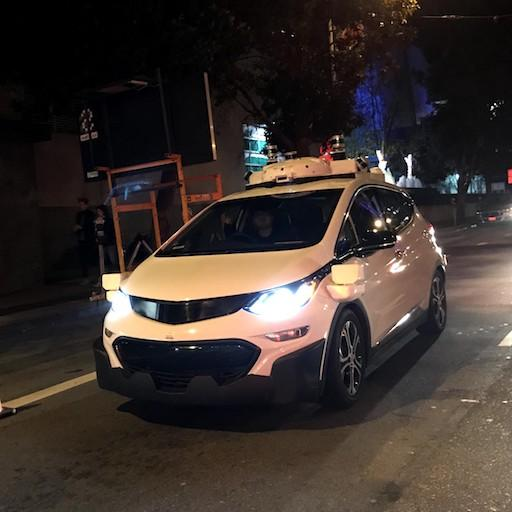

Variant: mirror
Model: VGG16
Prediction: minivan (86.11%)



In [25]:
#A8.4

os.makedirs("generated_images", exist_ok=True)

base = Image.open(IMG_PATH).convert("RGB")
w, h = base.size

variants = {
    "original": base,
    "mirror": ImageOps.mirror(base),
    "slight_blur": base.filter(ImageFilter.GaussianBlur(1.5)),
    "heavy_blur": base.filter(ImageFilter.GaussianBlur(4.0)),
    "rotated_90": base.rotate(90, expand=True),
    "rotated_180": base.rotate(180, expand=True),
    "grayscale": ImageOps.grayscale(base).convert("RGB"),
    "posterized": ImageOps.posterize(base, 2),
    "tiny_upscaled": base.resize((32, 32)).resize(base.size),
    "center_crop_large": base.crop((int(0.10*w), int(0.10*h), int(0.90*w), int(0.90*h))).resize(base.size),
    "center_crop_small": base.crop((int(0.25*w), int(0.25*h), int(0.75*w), int(0.75*h))).resize(base.size),
}

models_84 = [
    ("ResNet50", ResNet50(weights="imagenet"), resnet_preprocess_input, resnet_decode_predictions),
    ("VGG16", VGG16(weights="imagenet"), vgg_preprocess_input, vgg_decode_predictions),
]

records_84 = []

for variant_name, variant_img in variants.items():
    variant_path = os.path.join("generated_images", f"{variant_name}.jpg")
    variant_img.save(variant_path)

    for model_name, model, preprocess_fn, decode_fn in models_84:
        pred_label, pred_prob, top5 = predict_keras_top1(
            variant_path, model, preprocess_fn, decode_fn
        )

        records_84.append({
            "image": variant_path,
            "variant": variant_name,
            "model": model_name,
            "prediction": pred_label,
            "confidence": pred_prob * 100,
            "correct": is_car_like_prediction(pred_label),
        })

df_84 = pd.DataFrame(records_84).sort_values(
    ["correct", "confidence"], ascending=[False, False]
).reset_index(drop=True)

display(df_84)

correct_examples = df_84[df_84["correct"]].head(2)
incorrect_examples = df_84[~df_84["correct"]].head(2)

print("Two correctly classified examples:")
display(correct_examples[["image", "variant", "model", "prediction", "confidence"]])

print("Two incorrectly classified examples:")
display(incorrect_examples[["image", "variant", "model", "prediction", "confidence"]])

print("=== Correctly classified examples ===")
for _, row in correct_examples.iterrows():
    display(IPyImage(filename=row["image"], width=300))
    print(f"Variant: {row['variant']}")
    print(f"Model: {row['model']}")
    print(f"Prediction: {row['prediction']} ({row['confidence']:.2f}%)")
    print()

print("=== Incorrectly classified examples ===")
for _, row in incorrect_examples.iterrows():
    display(IPyImage(filename=row["image"], width=300))
    print(f"Variant: {row['variant']}")
    print(f"Model: {row['model']}")
    print(f"Prediction: {row['prediction']} ({row['confidence']:.2f}%)")
    print()

In [26]:
#A8.5
def benchmark_keras_on_available_devices(model_fn, x, runs=20, warmup=3):
    results = []

    mean_s, std_s = benchmark_keras_model(
        model_fn, x, runs=runs, warmup=warmup, device_name="/CPU:0"
    )
    results.append({
        "model": model_fn.__name__,
        "device": "CPU",
        "mean_ms": mean_s * 1000,
        "std_ms": std_s * 1000,
    })

    if tf.config.list_physical_devices("GPU"):
        mean_s, std_s = benchmark_keras_model(
            model_fn, x, runs=runs, warmup=warmup, device_name="/GPU:0"
        )
        results.append({
            "model": model_fn.__name__,
            "device": "GPU",
            "mean_ms": mean_s * 1000,
            "std_ms": std_s * 1000,
        })

    return results


results_85 = []
results_85.extend(benchmark_keras_on_available_devices(ResNet50, x_resnet_keras))
results_85.extend(benchmark_keras_on_available_devices(VGG16, x_vgg_keras))

df_85 = pd.DataFrame(results_85)
display(df_85)

if "GPU" in df_85["device"].values:
    compare_rows = []
    for model_name in df_85["model"].unique():
        cpu_ms = df_85[(df_85["model"] == model_name) & (df_85["device"] == "CPU")]["mean_ms"].iloc[0]
        gpu_ms = df_85[(df_85["model"] == model_name) & (df_85["device"] == "GPU")]["mean_ms"].iloc[0]
        compare_rows.append({
            "model": model_name,
            "cpu_ms": cpu_ms,
            "gpu_ms": gpu_ms,
            "speedup": cpu_ms / gpu_ms,
        })

    df_85_compare = pd.DataFrame(compare_rows)
    display(df_85_compare)
else:
    print("Keine GPU für TensorFlow sichtbar.")

,model,device,mean_ms,std_ms
0,ResNet50,CPU,399.773678,120.920837
1,ResNet50,GPU,250.221357,44.015693
2,VGG16,CPU,396.359353,88.162913
3,VGG16,GPU,26.002468,1.358211


,model,cpu_ms,gpu_ms,speedup
0,ResNet50,399.773678,250.221357,1.597680
1,VGG16,396.359353,26.002468,15.243144
